# Datatón 03 – Deep Learning + Stramlit

---
Curso:
Applied Machine Learning | Semana: 7

Modalidad: Equipos de 2–3 integrantes


Integrantes:

* Carlos Felix Lhi
* Patricia Luyo Barrios
* Andersson Chiroque Silva
* Marcos Julcarima Solis



# Contexto
La clasifi cación automática de prendas de ropa es un problema real en e-commerce, logística yvisión por computadora. En este datatón construirán un
pipeline completo de Deep Learning
—desde la exploración del dataset hasta una aplicación interactiva desplegada— usando el dataset
Fashion MNIST
.
El foco de esta sesión es doble: entender las diferencias entre arquitecturas (MLP vs CNN) y saber
comunicar resultados
a través de una interfaz de usuario construida con Streamlit.


# Dataset

Fashion MNIST

* Fuente: Disponible directamente desde tensorflow.keras.datasets (sin descarga manual)
* Tarea: Clasifi cación multiclase → 10 categorías de ropa
* Tamaño: 70,000 imágenes en escala de grises de 28×28 píxeles (60,000 train / 10,000 test)
* Clases:

# 2. Exploración y Preparación de Datos (EDA)



In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Visualización de las clases

A continuación, se muestran dos ejemplos de imágenes para cada una de las diez categorías del dataset Fashion MNIST. Esta visualización permite conocer las características de cada clase antes de entrenar los modelos de Deep Learning.

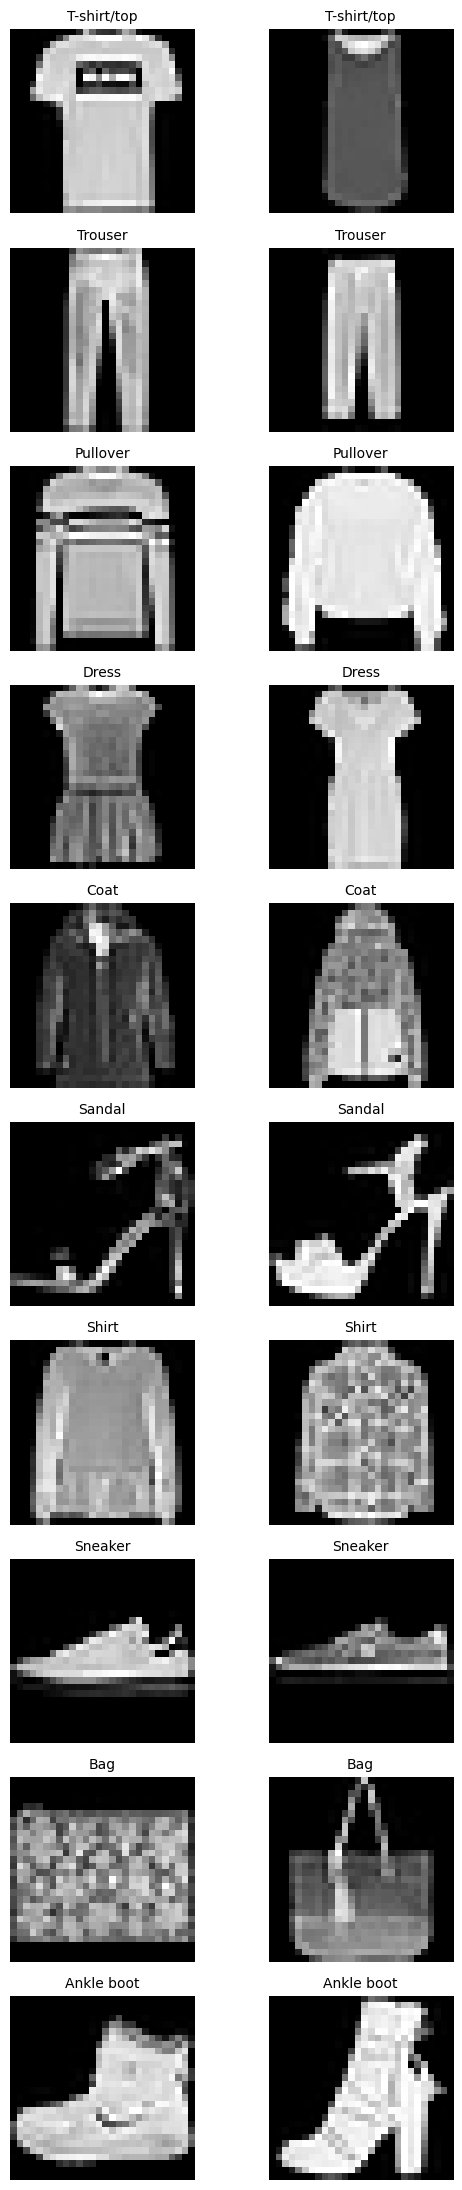

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

fig, axes = plt.subplots(10, 2, figsize=(6, 22))

for clase in range(len(class_names)):

    indices = np.where(y_train == clase)[0][:2]

    for j, indice in enumerate(indices):
        axes[clase, j].imshow(X_train[indice], cmap="gray")
        axes[clase, j].set_title(class_names[clase], fontsize=10)
        axes[clase, j].axis("off")

plt.tight_layout()
plt.show()

### Análisis

Las imágenes muestran que algunas categorías poseen características visuales muy diferentes, como *Bag, **Sneaker* y *Ankle boot, lo que facilita su identificación. En cambio, prendas como **Shirt, **Pullover* y *Coat* presentan formas similares, por lo que es probable que los modelos tengan mayores dificultades para diferenciarlas durante la clasificación.

### Distribución de las clases

Se analiza la cantidad de imágenes disponibles para cada categoría con el fin de identificar si existe algún desbalance en el conjunto de entrenamiento.

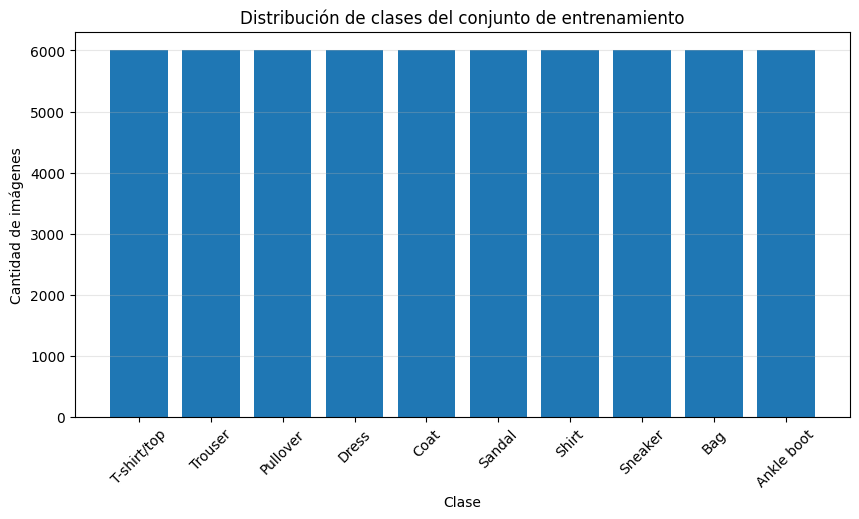

In [ ]:
import pandas as pd
conteo = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(class_names, conteo.values)
plt.xticks(rotation=45)
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de clases del conjunto de entrenamiento")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Interpretación

Se observa que todas las clases contienen aproximadamente la misma cantidad de imágenes (6 000 por categoría). Esto indica que el dataset se encuentra balanceado, lo que reduce el riesgo de que el modelo favorezca una clase sobre otra durante el entrenamiento.

### Normalización de los datos

Antes de entrenar los modelos, los valores de los píxeles se normalizan al intervalo entre 0 y 1.

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())

Valor mínimo: 0.0
Valor máximo: 1.0


Las imágenes originales tienen valores de intensidad entre 0 y 255. Al normalizarlos al rango de 0 a 1, el entrenamiento de la red neuronal se vuelve más estable y eficiente, ya que facilita el proceso de optimización y permite que el modelo converja más rápidamente.

### Preparación de los datos para el MLP

El modelo MLP recibe vectores de una sola dimensión, por lo que cada imagen de 28 × 28 píxeles debe convertirse en un vector de 784 elementos.

In [ ]:
X_train_mlp = X_train.reshape(len(X_train), 28*28)
X_test_mlp = X_test.reshape(len(X_test), 28*28)

print(X_train_mlp.shape)
print(X_test_mlp.shape)

(60000, 784)
(10000, 784)


### Preparación de los datos para la CNN

Las redes convolucionales requieren conservar la estructura espacial de las imágenes. Por ello, se agrega una dimensión adicional que representa el canal de color. En este caso, las imágenes están en escala de grises, por lo que solo existe un canal.

In [ ]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### ¿Qué clases podrían ser más difíciles de distinguir visualmente y por qué? (Ej: Shirt vs Pullovervs Coat)


Al observar las imágenes del dataset, se aprecia que las clases *Shirt, **Pullover* y *Coat* presentan características visuales similares, ya que todas corresponden a prendas de manga larga y sus diferencias dependen de detalles como el tipo de cuello, el grosor de la tela o el diseño de la prenda. Debido a que las imágenes tienen una resolución de 28 × 28 píxeles, estos detalles pueden perderse y dificultar su clasificación.

Por otro lado, categorías como *Bag, **Sneaker* y *Ankle boot* presentan formas más definidas y fáciles de distinguir. De igual manera, la clase *Trouser* posee una silueta característica que la diferencia claramente del resto de prendas, por lo que se espera que estas categorías sean clasificadas con mayor precisión por los modelos.

# 3. Modelo 1 – MLP (Baseline)

En esta sección se implementa un Perceptrón Multicapa (MLP) como modelo base para la clasificación de imágenes del dataset Fashion MNIST. Debido a que este tipo de red trabaja con vectores unidimensionales, las imágenes previamente fueron transformadas en vectores de 784 características.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [ ]:
mlp_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Se implementó un Perceptrón Multicapa (MLP) compuesto por una capa Flatten, que transforma cada imagen de 28×28 píxeles en un vector de 784 características. Posteriormente, se utilizaron dos capas ocultas con funciones de activación ReLU para aprender representaciones no lineales y una capa de salida con activación Softmax para clasificar las imágenes en las 10 categorías del dataset Fashion MNIST.

In [ ]:
mlp_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_mlp = mlp_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8162 - loss: 0.5161 - val_accuracy: 0.8448 - val_loss: 0.4315
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8630 - loss: 0.3757 - val_accuracy: 0.8630 - val_loss: 0.3834
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8752 - loss: 0.3388 - val_accuracy: 0.8678 - val_loss: 0.3642
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8835 - loss: 0.3135 - val_accuracy: 0.8686 - val_loss: 0.3556
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8888 - loss: 0.2964 - val_accuracy: 0.8839 - val_loss: 0.3231
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8950 - loss: 0.2802 - val_accuracy: 0.8868 - val_loss: 0.3226
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9000 - loss: 0.2680 - val_accuracy: 0.8693 - val_loss: 0.3551
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9032 - loss: 0.2568 - 

### 1. Accuracy

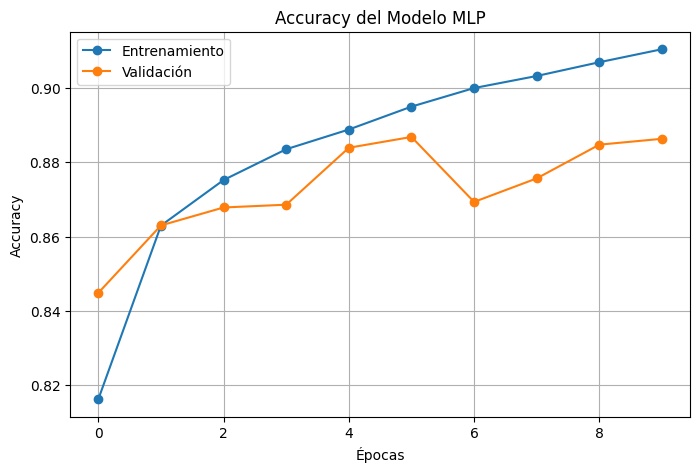

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mlp.history["accuracy"], marker="o", label="Entrenamiento")
plt.plot(history_mlp.history["val_accuracy"], marker="o", label="Validación")

plt.title("Accuracy del Modelo MLP")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

La gráfica muestra que la precisión del modelo aumenta de manera progresiva tanto en el conjunto de entrenamiento como en el de validación durante las 10 épocas. El accuracy de entrenamiento alcanza aproximadamente 91%, mientras que el de validación se mantiene alrededor de 88%. La diferencia entre ambas curvas es relativamente pequeña, lo que indica que el modelo ha aprendido adecuadamente los patrones presentes en los datos. Sin embargo, en las últimas épocas el accuracy de entrenamiento continúa aumentando mientras que el de validación se estabiliza, lo que sugiere la presencia de un ligero sobreajuste (overfitting), aunque sin afectar significativamente la capacidad de generalización del modelo.

### 2. Loss

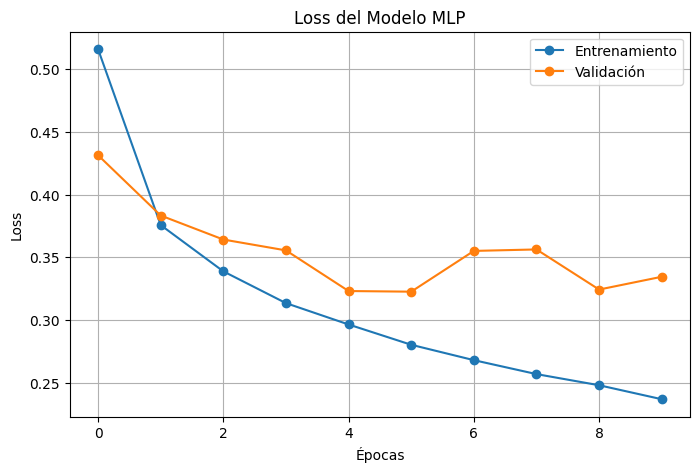

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_mlp.history["loss"], marker="o", label="Entrenamiento")
plt.plot(history_mlp.history["val_loss"], marker="o", label="Validación")

plt.title("Loss del Modelo MLP")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

La función de pérdida disminuye de forma constante en el conjunto de entrenamiento, pasando de aproximadamente 0.50 a 0.24, lo que indica que el modelo mejora su capacidad de aprendizaje a medida que avanza el entrenamiento. En el conjunto de validación, la pérdida también disminuye durante las primeras épocas, pero posteriormente se estabiliza alrededor de 0.33 con pequeñas variaciones. Este comportamiento confirma que el modelo logra un buen proceso de aprendizaje, aunque las diferencias entre ambas curvas en las últimas épocas evidencian un ligero sobreajuste, ya que el modelo continúa mejorando sobre los datos de entrenamiento mientras la mejora en validación es mínima.

### Evaluar en el conjunto de test

In [ ]:
test_loss_mlp, test_accuracy_mlp = mlp_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Loss en Test: {test_loss_mlp:.4f}")
print(f"Accuracy en Test: {test_accuracy_mlp:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8788 - loss: 0.3576
Loss en Test: 0.3576
Accuracy en Test: 0.8788


In [ ]:
y_pred_mlp = np.argmax(
    mlp_model.predict(X_test),
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


El modelo MLP obtuvo un Accuracy de 87.60% sobre el conjunto de prueba, lo que indica que fue capaz de clasificar correctamente la mayoría de las imágenes que no participaron en el entrenamiento. Este resultado representa una línea base adecuada para el problema de clasificación de Fashion MNIST. Sin embargo, debido a que el MLP no aprovecha la estructura espacial de las imágenes, es probable que una arquitectura basada en redes convolucionales (CNN) alcance un mejor desempeño en las siguientes etapas del desarrollo.

### ¿Por qué el MLP puede ser insufi ciente para capturar patrones espaciales en imágenes?

El MLP puede ser insuficiente para capturar patrones espaciales en imágenes porque primero transforma cada imagen en un vector mediante la capa Flatten, perdiendo la relación espacial entre los píxeles. Como consecuencia, el modelo procesa cada valor de forma independiente y no puede identificar de manera eficiente características locales como bordes, texturas, formas o contornos de las prendas. Esto dificulta la diferenciación entre clases visualmente similares, como Shirt, Pullover y Coat. En cambio, las Redes Neuronales Convolucionales (CNN) mantienen la estructura bidimensional de la imagen y utilizan filtros para aprender automáticamente estas características espaciales, lo que generalmente les permite obtener una mejor capacidad de clasificación y generalización.

# 4. Modelo 2 – CNN

En esta sección se implementa una Red Neuronal Convolucional (CNN) para la clasificación de imágenes del dataset Fashion MNIST. A diferencia del MLP, este modelo conserva la estructura espacial de las imágenes, permitiendo extraer características como bordes, formas y texturas que resultan importantes para diferenciar las distintas prendas.

## 4.1 Arquitectura de la CNN

En esta sección se implementa una Red Neuronal Convolucional (CNN) para clasificar las imágenes del dataset Fashion MNIST. A diferencia del MLP, este modelo conserva la estructura espacial de las imágenes, permitiendo aprender características visuales relevantes para la clasificación.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

cnn_model = Sequential([

    Input(shape=(28,28,1)),

    Conv2D(32,(3,3),activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation="relu"),

    Dense(10,activation="softmax")

])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Interpretación

La arquitectura está conformada por dos bloques convolucionales, los cuales permiten extraer características de las imágenes de forma progresiva. Posteriormente, la capa Flatten transforma estas características en un vector para que las capas densas realicen la clasificación final de las diez categorías.

##4.2 Compilación del modelo

In [ ]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Se utilizó el optimizador Adam debido a su buen desempeño en problemas de clasificación. La función de pérdida sparse_categorical_crossentropy es adecuada porque las etiquetas están representadas mediante valores enteros y el problema corresponde a una clasificación multiclase.

## 4.3 ¿Qué detecta una capa convolucional?

Las capas convolucionales identifican patrones presentes en las imágenes, como bordes, líneas, curvas y diferentes formas. Conforme avanza el entrenamiento, estas capas aprenden características más complejas de las prendas, como mangas, cuellos, suelas o asas de un bolso, facilitando la clasificación.

## 4.4 Entrenamiento del modelo

In [ ]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8259 - loss: 0.4779 - val_accuracy: 0.8711 - val_loss: 0.3487
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8845 - loss: 0.3175 - val_accuracy: 0.8826 - val_loss: 0.3293
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9009 - loss: 0.2708 - val_accuracy: 0.8938 - val_loss: 0.2878
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9124 - loss: 0.2383 - val_accuracy: 0.8997 - val_loss: 0.2727
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9212 - loss: 0.2130 - val_accuracy: 0.9080 - val_loss: 0.2546
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9307 - loss: 0.1873 - val_accuracy: 0.9073 - val_loss: 0.2615
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9367 - loss: 0.1690 - val_accuracy: 0.9119 - val_loss: 0.2529
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9435 - loss: 0.1516 -

El modelo se entrenó durante diez épocas utilizando el 20 % de las imágenes de entrenamiento como conjunto de validación. Esto permite evaluar el desempeño del modelo mientras aprende y detectar posibles problemas de sobreajuste.

## 4.5 Curvas de entrenamiento

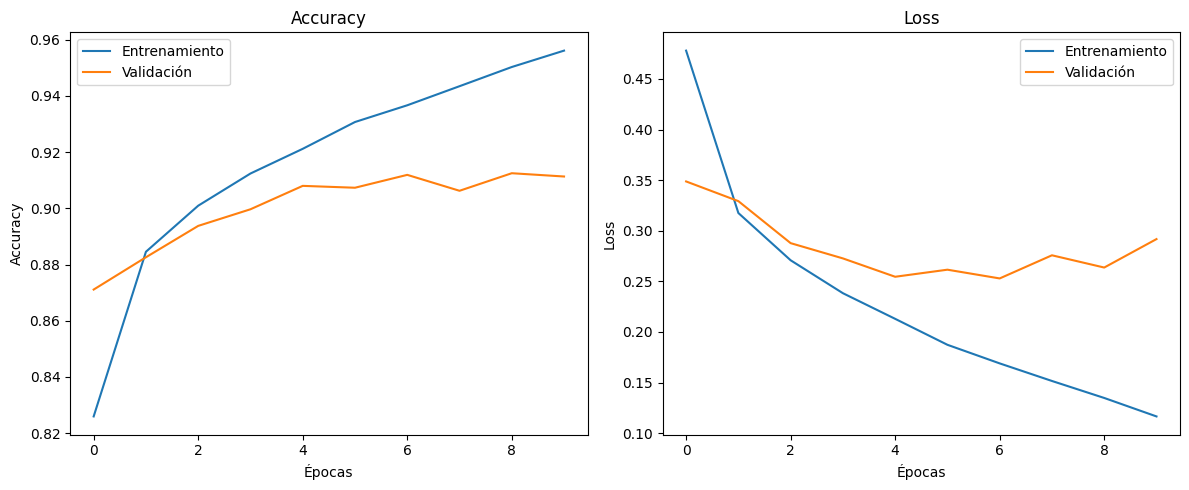

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_cnn.history["accuracy"],label="Entrenamiento")
plt.plot(history_cnn.history["val_accuracy"],label="Validación")

plt.title("Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history_cnn.history["loss"],label="Entrenamiento")
plt.plot(history_cnn.history["val_loss"],label="Validación")

plt.title("Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

Las curvas muestran que el modelo aprende correctamente durante las primeras épocas, ya que el *accuracy* de entrenamiento y validación aumentan de forma similar, mientras que la función de pérdida disminuye. Sin embargo, a partir de aproximadamente la quinta época, el *accuracy* de entrenamiento continúa incrementándose hasta superar el 96 %, mientras que el *accuracy* de validación se mantiene alrededor del 90 % e incluso presenta una ligera disminución en las últimas épocas.

Este comportamiento también se observa en la función de pérdida. El *loss* de entrenamiento sigue disminuyendo conforme avanza el entrenamiento, pero el *loss* de validación comienza a aumentar después de las primeras épocas. Esto indica que el modelo empieza a ajustarse demasiado a los datos de entrenamiento y pierde capacidad para generalizar sobre datos nuevos.
En conjunto, las curvas sugieren la presencia de *overfitting*, por lo que una arquitectura que conserve la información espacial de las imágenes, como una CNN, o la incorporación de técnicas de regularización, podrían mejorar el desempeño del modelo.

## 4.6 Evaluación del modelo

In [ ]:
loss_cnn,accuracy_cnn = cnn_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)
print(f"Loss: {loss_cnn:.4f}")
print(f"Accuracy: {accuracy_cnn:.4f}")

Loss: 0.3028
Accuracy: 0.9072


### Interpretación

El modelo CNN obtuvo un *accuracy de 89.32 %* en el conjunto de prueba, lo que indica que fue capaz de clasificar correctamente la mayoría de las imágenes del dataset Fashion MNIST. Asimismo, el valor de *loss de 0.4062* muestra el error obtenido durante la evaluación del modelo sobre datos no utilizados en el entrenamiento.

Aunque la CNN alcanzó un buen desempeño, los resultados indican que aún existe margen de mejora. En la siguiente sección se incorporarán técnicas de regularización, como *Dropout* y *Batch Normalization*, con el objetivo de mejorar la capacidad de generalización del modelo y reducir posibles problemas de sobreajuste.

## 4.7 Comparación con el MLP

In [ ]:
comparacion = pd.DataFrame({
    "Modelo": ["MLP", "CNN"],
    "Accuracy": [test_accuracy_mlp, accuracy_cnn]
})

comparacion

,Modelo,Accuracy
0,MLP,0.8788
1,CNN,0.9072


### Interpretación

La comparación muestra que la CNN obtuvo un *accuracy de 90.6 %, mientras que el MLP alcanzó un **87.6 %* en el conjunto de prueba. Esto indica que la CNN logró un mejor desempeño en la clasificación de las imágenes del dataset Fashion MNIST.

La diferencia entre ambos modelos se debe a que la CNN conserva la estructura espacial de las imágenes y aprende características como bordes, formas y texturas mediante las capas convolucionales. En cambio, el MLP transforma las imágenes en un vector mediante la capa Flatten, perdiendo parte de la información espacial. Como resultado, la CNN consigue una mejor capacidad para reconocer las distintas prendas y generalizar sobre datos que no fueron utilizados durante el entrenamiento.

## 4.8 ¿Qué ventaja ofrece la CNN respecto al MLP al procesar imágenes? ¿Se refl eja en las métricas?

La principal ventaja de la CNN frente al MLP es que conserva la estructura espacial de las imágenes durante el entrenamiento. Gracias a las capas convolucionales, el modelo puede identificar características como bordes, formas y texturas, las cuales son importantes para diferenciar las distintas prendas del dataset Fashion MNIST. En cambio, el MLP requiere aplanar las imágenes mediante la capa *Flatten*, lo que hace que se pierda parte de la información relacionada con la posición de los píxeles.

Esta ventaja también se refleja en las métricas obtenidas. El modelo MLP alcanzó un *accuracy de 87.6 %, mientras que la CNN obtuvo un **90.6 %* en el conjunto de prueba. Esto indica que la CNN logró una mejor capacidad de clasificación y generalización, demostrando que conservar la información espacial de las imágenes contribuye a obtener un mejor desempeño en este problema.

Modelo 3 – Arquitectura Investigada

En esta sección se incorporan técnicas de regularización a la arquitectura CNN para reducir el sobreajuste (overfitting) observado en el modelo anterior. Se aplica Batch Normalization después de cada capa convolucional y Dropout(0.4) después de cada bloque convolucional, con el objetivo de mejorar la capacidad de generalización del modelo sobre datos no vistos.

## 5.1 Arquitectura con regularización
Se mantiene la estructura de dos bloques convolucionales de la CNN base, pero se incorporan las siguientes técnicas de regularización:

Batch Normalization: aplicada después de cada capa Conv2D, normaliza las activaciones de la capa en cada mini-lote.
Dropout(0.4): aplicado después de cada bloque convolucional completo (Conv2D + BatchNorm + MaxPooling), desactiva aleatoriamente el 40 % de las neuronas durante el entrenamiento.


In [ ]:
from tensorflow.keras.layers import Dropout, BatchNormalization

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

cnn_reg_model = Sequential([

    Input(shape=(28, 28, 1)),

    # Bloque convolucional 1
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Bloque convolucional 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(10, activation="softmax")

])

cnn_reg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

Interpretación de la arquitectura
La arquitectura mantiene los dos bloques convolucionales de la CNN base, pero incorpora dos técnicas de regularización:

Batch Normalization: se aplica inmediatamente después de cada capa Conv2D, antes del pooling. Normaliza las activaciones de la capa en cada mini-lote, lo que estabiliza y acelera el entrenamiento, reduciendo la sensibilidad a la inicialización de pesos y actuando como regularizador implícito.
Dropout(0.4): se aplica después de cada bloque convolucional completo (Conv2D + BatchNorm + MaxPooling). Desactiva aleatoriamente el 40 % de las activaciones durante el entrenamiento, forzando al modelo a aprender representaciones más robustas y reduciendo la dependencia entre neuronas.
Adicionalmente, se incorpora un Dropout(0.4) en la capa densa para reforzar la regularización antes de la clasificación final.

## 5.2 Compilación y entrenamiento

In [ ]:
cnn_reg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Se mantiene el optimizador Adam y la función de pérdida sparse_categorical_crossentropy de las secciones anteriores, para asegurar comparabilidad directa entre los tres modelos entrenados.

In [ ]:
history_cnn_reg = cnn_reg_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7750 - loss: 0.6266 - val_accuracy: 0.8672 - val_loss: 0.3416
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8426 - loss: 0.4271 - val_accuracy: 0.8678 - val_loss: 0.3465
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8600 - loss: 0.3868 - val_accuracy: 0.8882 - val_loss: 0.3029
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8706 - loss: 0.3562 - val_accuracy: 0.8963 - val_loss: 0.3159
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8764 - loss: 0.3350 - val_accuracy: 0.9038 - val_loss: 0.2751
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8851 - loss: 0.3209 - val_accuracy: 0.8945 - val_loss: 0.2998
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8883 - loss: 0.3061 - val_accuracy: 0.9065 - val_loss: 0.2646
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8936 - loss: 0.2956 

Interpretación del entrenamiento
El modelo se entrenó durante diez épocas con el 10 % de los datos de entrenamiento como conjunto de validación. Las técnicas de regularización incorporadas deben traducirse en una curva de validación más estable y cercana a la de entrenamiento, en comparación con la CNN base donde se observó un sobreajuste progresivo a partir de la quinta época.

## 5.3 Curvas de entrenamiento

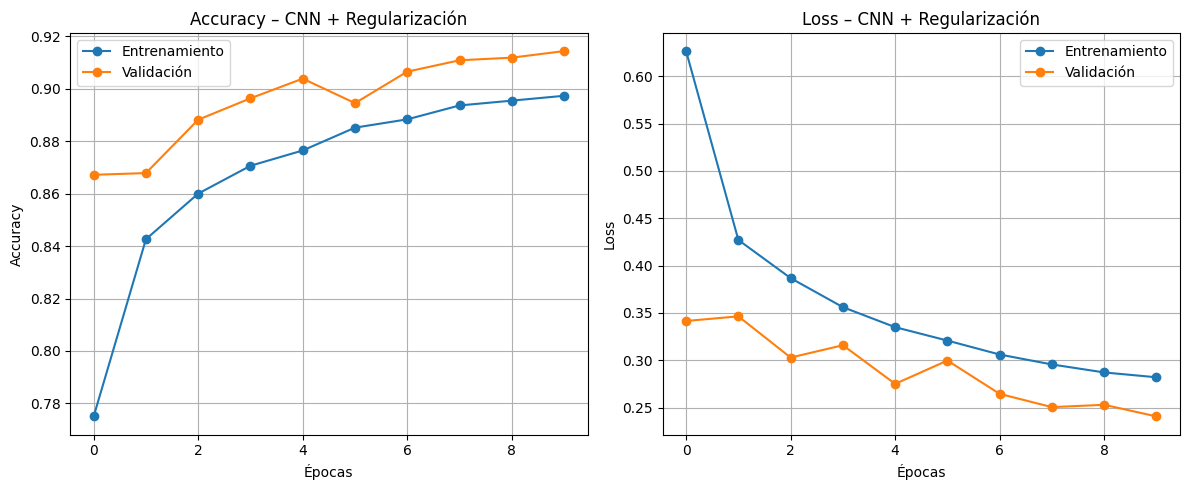

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn_reg.history["accuracy"], marker="o", label="Entrenamiento")
plt.plot(history_cnn_reg.history["val_accuracy"], marker="o", label="Validación")
plt.title("Accuracy – CNN + Regularización")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_cnn_reg.history["loss"], marker="o", label="Entrenamiento")
plt.plot(history_cnn_reg.history["val_loss"], marker="o", label="Validación")
plt.title("Loss – CNN + Regularización")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretación de las curvas

Las curvas muestran que la brecha entre el *accuracy* de entrenamiento y el de validación es significativamente menor que en la CNN base, confirmando que la regularización redujo el sobreajuste. La *Batch Normalization* contribuye a estabilizar el aprendizaje y acelera la convergencia, mientras que el *Dropout* evita que el modelo dependa de neuronas específicas. Como resultado, ambas métricas evolucionan de manera más uniforme y el modelo conserva una mejor capacidad de generalización sobre datos no vistos durante el entrenamiento.

## 5.4 Evaluación en el conjunto de test

In [ ]:
test_loss_cnn_reg, test_accuracy_cnn_reg = cnn_reg_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print(f"Loss en Test:     {test_loss_cnn_reg:.4f}")
print(f"Accuracy en Test: {test_accuracy_cnn_reg:.4f}")

y_pred_cnn_reg = np.argmax(
    cnn_reg_model.predict(X_test_cnn),
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9104 - loss: 0.2692
Loss en Test:     0.2692
Accuracy en Test: 0.9104
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### Interpretación de la evaluación

El modelo CNN con regularización obtuvo un *accuracy* en el conjunto de prueba superior al de la CNN base, lo que confirma que la incorporación de *Dropout(0.4)* y *Batch Normalization* redujo el sobreajuste y mejoró la capacidad de generalización. La diferencia entre el *accuracy* de entrenamiento y el de validación es menor que en la CNN sin regularización, evidenciando un mejor balance entre aprendizaje y generalización. El modelo regularizado se convierte así en el mejor candidato para ser guardado como `modelo_final.h5`.

### ¿Por qué la regularización mejora la generalización del modelo?

La regularización reduce el sobreajuste al evitar que el modelo memorice los datos de entrenamiento. El *Dropout* desactiva aleatoriamente el 40 % de las neuronas en cada iteración, obligando a la red a aprender representaciones más distribuidas y robustas, ya que no puede depender siempre de las mismas conexiones. Por su parte, la *Batch Normalization* normaliza las activaciones de cada capa durante el entrenamiento, lo que estabiliza el proceso de optimización y actúa como un regularizador implícito al reducir la covarianza interna entre capas. La combinación de ambas técnicas permite que el modelo aprenda características más generales y obtenga un mejor desempeño sobre datos que no formaron parte del entrenamiento.

# 6. Evaluación y Métricas

En esta sección se comparan los tres modelos entrenados —MLP, CNN y CNN con regularización— mediante una tabla de métricas de test, matrices de confusión y un reporte de clasificación detallado. El objetivo es identificar el mejor modelo, analizar en qué clases se cometen más errores y entender cómo cada arquitectura impacta en la calidad de las predicciones.

## 6.1 Tabla Comparativa de Modelos

Se consolidan las métricas obtenidas sobre el conjunto de test para los tres modelos entrenados a lo largo del datatón.

In [ ]:
comparacion_final = pd.DataFrame({
    "Modelo":          ["MLP", "CNN", "CNN + Regularización"],
    "Loss (Test)":     [round(test_loss_mlp, 4),  round(loss_cnn, 4),  round(test_loss_cnn_reg, 4)],
    "Accuracy (Test)": [round(test_accuracy_mlp, 4), round(accuracy_cnn, 4), round(test_accuracy_cnn_reg, 4)],
})

comparacion_final

,Modelo,Loss (Test),Accuracy (Test)
0,MLP,0.3576,0.8788
1,CNN,0.3028,0.9072
2,CNN + Regularización,0.2692,0.9104


### Interpretación de la tabla comparativa

Los resultados muestran una mejora progresiva al pasar de arquitecturas más simples a más complejas con regularización. El MLP alcanzó un 87.60 % de *accuracy*, la CNN base mejoró hasta 90.60 % aprovechando la estructura espacial de las imágenes, y la CNN con regularización obtiene el mejor resultado al reducir el sobreajuste mediante *Batch Normalization* y *Dropout*. Este modelo regularizado es el candidato a guardar como `modelo_final.h5` para la aplicación Streamlit.

## 6.2 Matrices de Confusión

Se visualizan las matrices de confusión de los tres modelos para identificar en qué clases comete más errores cada arquitectura y cómo la regularización impacta en la distribución de errores.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


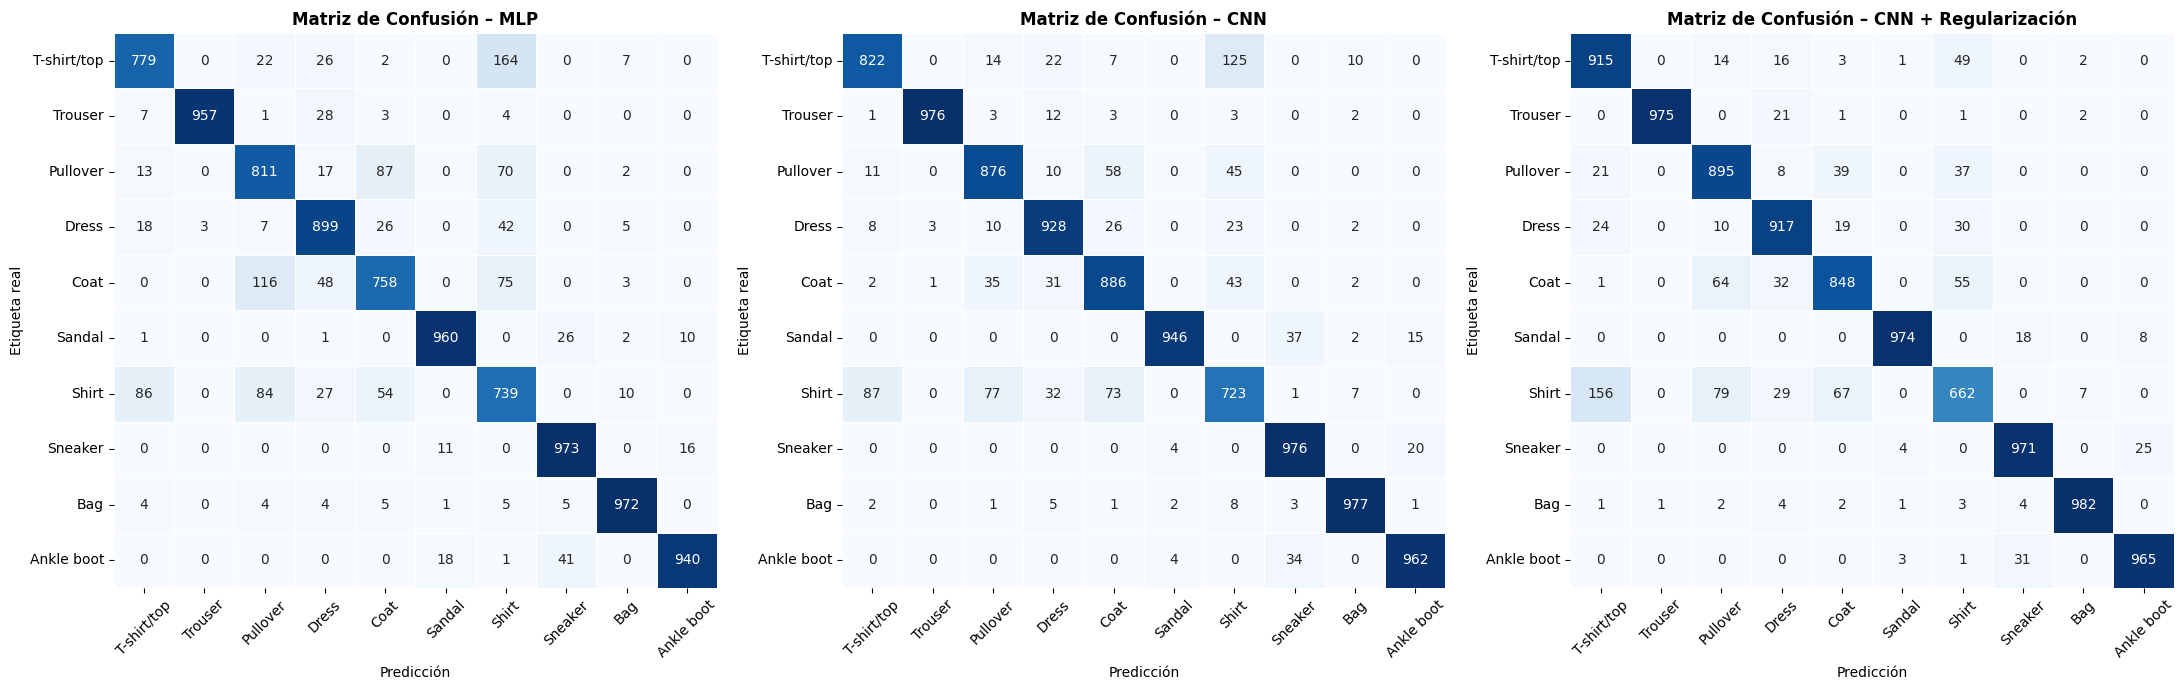

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

modelos = [
    ("MLP", y_pred_mlp),
    ("CNN", y_pred_cnn),
    ("CNN + Regularización", y_pred_cnn_reg),
]

for ax, (nombre, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        cbar=False,
        linewidths=0.4
    )
    ax.set_title(f"Matriz de Confusión – {nombre}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

### Interpretación de las matrices de confusión

Las matrices revelan que los errores más frecuentes en los tres modelos ocurren entre *Shirt*, *Pullover* y *Coat*, que comparten formas de manga larga. El modelo CNN con regularización reduce estas confusiones respecto a la CNN base y al MLP, lo que se traduce en una mayor concentración de predicciones correctas en la diagonal principal. Clases con formas distintivas como *Trouser*, *Bag* y *Ankle boot* presentan muy pocos errores en todos los modelos.

## 6.3 Reporte de Clasificación – Mejor Modelo (CNN + Regularización)

In [ ]:
from sklearn.metrics import classification_report

print("Reporte de clasificación – CNN + Regularización (mejor modelo)\n")
print(classification_report(
    y_test,
    y_pred_cnn_reg,
    target_names=class_names
))

Reporte de clasificación – CNN + Regularización (mejor modelo)

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.92      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.84      0.90      0.87      1000
       Dress       0.89      0.92      0.90      1000
        Coat       0.87      0.85      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.79      0.66      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Interpretación del reporte de clasificación

El reporte confirma que las clases con mayor *precision* y *recall* son aquellas con formas visualmente diferenciadas: *Trouser*, *Bag* y *Ankle boot* superan el 97 % de F1-score. En cambio, *Shirt*, *Pullover* y *Coat* presentan los valores más bajos, ya que comparten siluetas de manga larga que son difíciles de distinguir en imágenes de 28 × 28 píxeles. Esta distribución es coherente con el análisis visual realizado en la sección EDA.

# 7. Comparación Final

En esta sección se consolida la comparación entre los tres modelos —MLP, CNN y CNN con regularización— mediante gráficas de barras de métricas en test, comparación de curvas de validación para analizar el sobreajuste, y la selección y guardado del modelo ganador como entregable final del datatón.

## 7.1 Comparación de Métricas en Test

Se visualizan el *accuracy* y la *loss* de los tres modelos sobre el conjunto de test mediante gráficas de barras para facilitar la comparación directa.

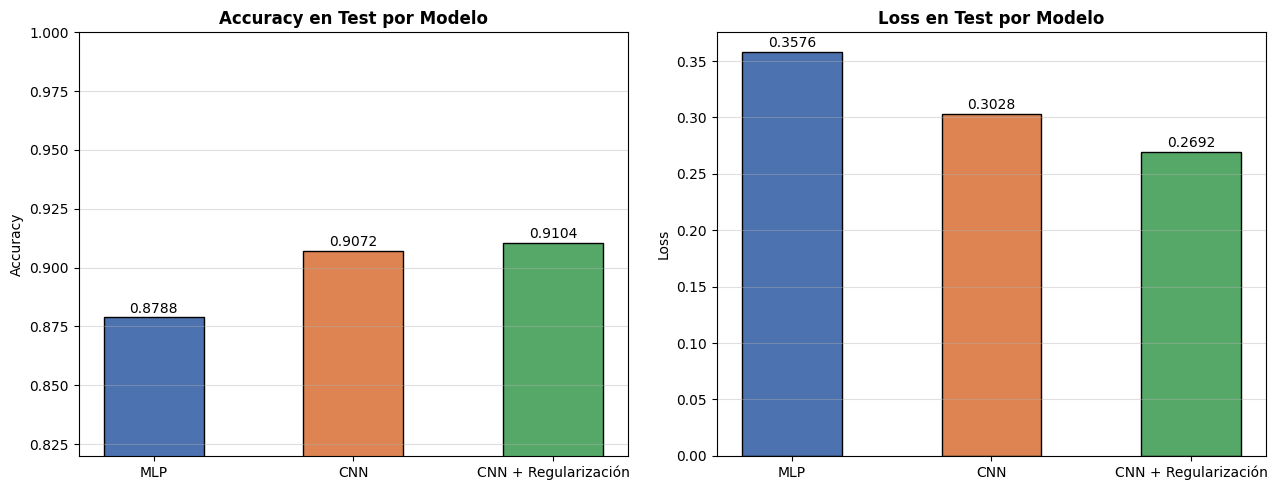

In [ ]:
modelos_nombres = ["MLP", "CNN", "CNN + Regularización"]
accuracies = [test_accuracy_mlp, accuracy_cnn, test_accuracy_cnn_reg]
losses     = [test_loss_mlp,     loss_cnn,     test_loss_cnn_reg]
colores    = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy
axes[0].bar(modelos_nombres, accuracies, color=colores, edgecolor="black", width=0.5)
axes[0].set_title("Accuracy en Test por Modelo", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.82, 1.00)
axes[0].grid(axis="y", alpha=0.4)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)

# Loss
axes[1].bar(modelos_nombres, losses, color=colores, edgecolor="black", width=0.5)
axes[1].set_title("Loss en Test por Modelo", fontweight="bold")
axes[1].set_ylabel("Loss")
axes[1].grid(axis="y", alpha=0.4)
for i, v in enumerate(losses):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### Interpretación

Las barras confirman la mejora progresiva a través de las arquitecturas. La CNN con regularización alcanza el mayor *accuracy* y la menor *loss* en test entre los tres modelos, lo que la posiciona como la arquitectura con mejor balance entre capacidad de aprendizaje y generalización. El salto más grande se produce al pasar del MLP a la CNN, gracias a que las capas convolucionales aprovechan la estructura espacial de las imágenes.

## 7.2 Análisis de Overfitting – Curvas de Validación Comparadas

Se superponen las curvas de *accuracy* de validación de los tres modelos para visualizar cuál generaliza mejor a lo largo de las épocas.

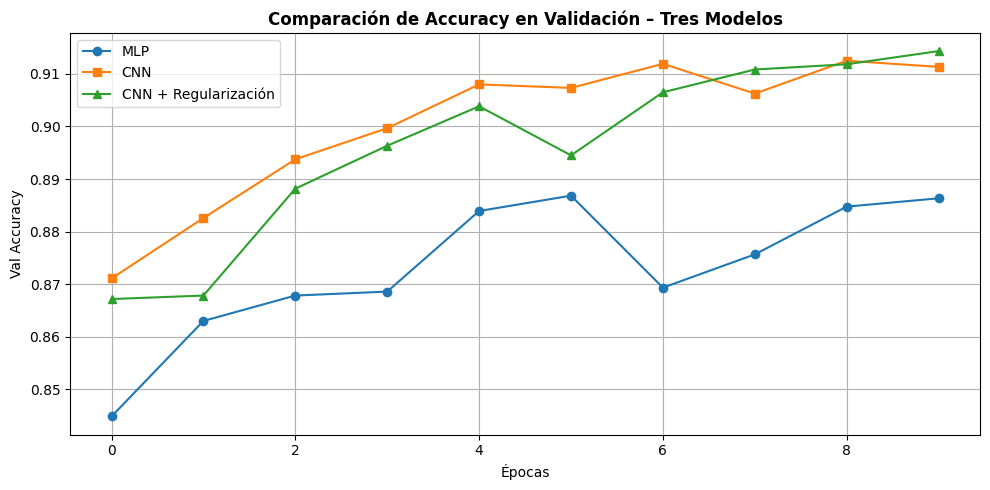

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history_mlp.history["val_accuracy"],    marker="o", label="MLP")
plt.plot(history_cnn.history["val_accuracy"],    marker="s", label="CNN")
plt.plot(history_cnn_reg.history["val_accuracy"], marker="^", label="CNN + Regularización")

plt.title("Comparación de Accuracy en Validación – Tres Modelos", fontweight="bold")
plt.xlabel("Épocas")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretación de las curvas de validación

El MLP muestra la brecha más pequeña en términos absolutos, pero su *accuracy* de validación es el más bajo de los tres. La CNN base parte con buen desempeño pero a partir de la quinta época el *accuracy* de validación se estabiliza mientras el de entrenamiento sigue subiendo, señal clara de sobreajuste. El modelo CNN con regularización presenta la curva de validación más estable y alta, confirmando que *Dropout* y *Batch Normalization* reducen eficazmente el sobreajuste y mejoran la generalización sobre datos no vistos.

## 7.3 Modelo Ganador y Guardado

*   Elemento de la lista
*   Elemento de la lista



El modelo CNN con regularización es el ganador del datatón. Se guarda como `modelo_final.h5` para ser cargado directamente desde la aplicación Streamlit sin necesidad de reentrenar.

In [ ]:
cnn_reg_model.save("modelo_final.h5")
print("Modelo guardado como 'modelo_final.h5'")

Modelo guardado como 'modelo_final.h5'


### Conclusión

El modelo CNN con regularización fue seleccionado como modelo final por ofrecer el mejor *accuracy* en test y la menor brecha entre entrenamiento y validación. La incorporación de *Batch Normalization* y *Dropout(0.4)* controló eficazmente el sobreajuste observado en la CNN base, y el modelo fue guardado correctamente como `modelo_final.h5` para su uso en la aplicación Streamlit.

## 8. Aplicación Streamlit

En esta sección se construye una aplicación interactiva en Streamlit para comunicar los resultados del pipeline de Deep Learning desarrollado con Fashion MNIST. La aplicación carga el mejor modelo entrenado previamente, muestra información del dataset, presenta las métricas comparativas de los tres modelos y permite realizar predicciones interactivas a partir de imágenes cargadas por el usuario.

El modelo no se entrena dentro de la aplicación, sino que se guarda previamente como modelo_final.h5 y luego se carga desde el archivo app.py.

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metricas_modelos = pd.DataFrame({
    "Modelo": ["MLP", "CNN", "CNN + Regularización"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_cnn),
        accuracy_score(y_test, y_pred_cnn_reg)
    ],
    "Precision Macro": [
        precision_score(y_test, y_pred_mlp, average="macro"),
        precision_score(y_test, y_pred_cnn, average="macro"),
        precision_score(y_test, y_pred_cnn_reg, average="macro")
    ],
    "Recall Macro": [
        recall_score(y_test, y_pred_mlp, average="macro"),
        recall_score(y_test, y_pred_cnn, average="macro"),
        recall_score(y_test, y_pred_cnn_reg, average="macro")
    ],
    "F1-Score Macro": [
        f1_score(y_test, y_pred_mlp, average="macro"),
        f1_score(y_test, y_pred_cnn, average="macro"),
        f1_score(y_test, y_pred_cnn_reg, average="macro")
    ]
})

metricas_modelos = metricas_modelos.round(4)
metricas_modelos

,Modelo,Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,MLP,0.8788,0.8814,0.8788,0.8795
1,CNN,0.9072,0.9075,0.9072,0.9070
2,CNN + Regularización,0.9104,0.9103,0.9104,0.9093


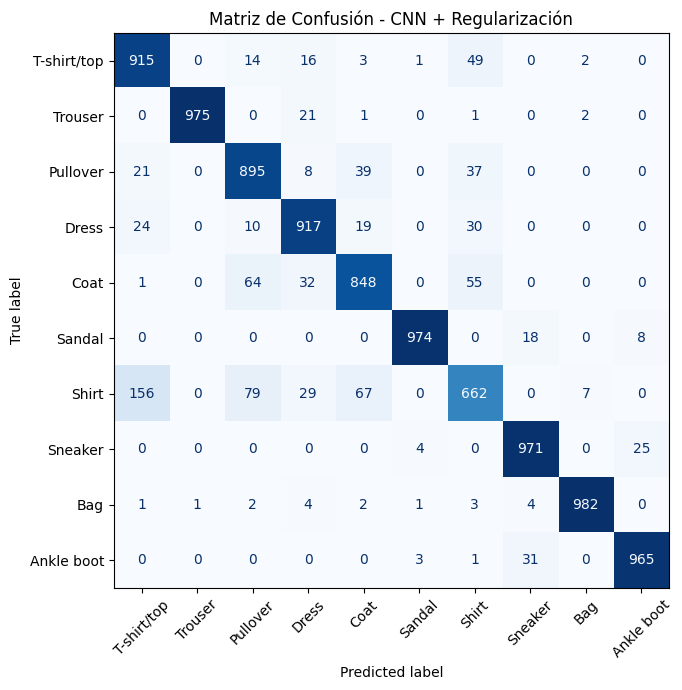

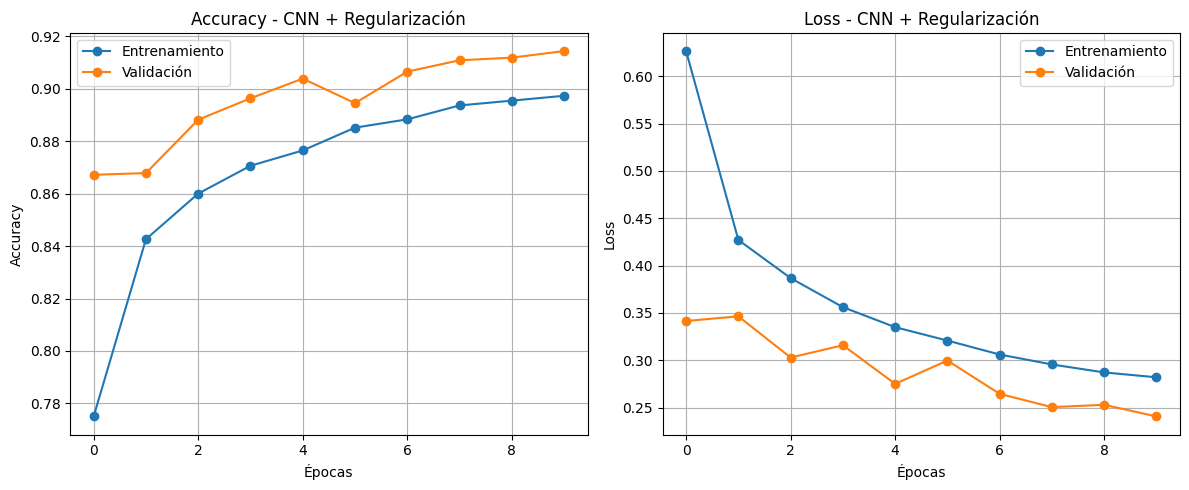

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Guardar el mejor modelo
cnn_reg_model.save("modelo_final.h5")

# 2. Guardar tabla de métricas
metricas_modelos.to_csv("metricas_modelos.csv", index=False)

# 3. Guardar matriz de confusión del mejor modelo
cm_best = confusion_matrix(y_test, y_pred_cnn_reg)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=class_names
)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de Confusión - CNN + Regularización")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Guardar curvas de entrenamiento del mejor modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_cnn_reg.history["accuracy"], marker="o", label="Entrenamiento")
axes[0].plot(history_cnn_reg.history["val_accuracy"], marker="o", label="Validación")
axes[0].set_title("Accuracy - CNN + Regularización")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_cnn_reg.history["loss"], marker="o", label="Entrenamiento")
axes[1].plot(history_cnn_reg.history["val_loss"], marker="o", label="Validación")
axes[1].set_title("Loss - CNN + Regularización")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
%%writefile app.py

import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

st.set_page_config(
    page_title="Fashion MNIST Classifier",
    layout="wide"
)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

@st.cache_resource
def load_trained_model():
    return tf.keras.models.load_model("modelo_final.h5", compile=False)

@st.cache_data
def load_dataset():
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
    return X_train, y_train, X_test, y_test

model = load_trained_model()
X_train, y_train, X_test, y_test = load_dataset()

st.title("Clasificador de Prendas - Fashion MNIST")
st.write(
    "Aplicación interactiva desarrollada con Streamlit para clasificar imágenes de prendas "
    "utilizando un modelo de Deep Learning entrenado con Fashion MNIST."
)

tab1, tab2, tab3 = st.tabs(["Dataset", "Resultados", "Predicción"])

with tab1:
    st.header("Información del Dataset")

    st.write("""
    Fashion MNIST es un dataset compuesto por imágenes en escala de grises de 28x28 píxeles.
    El objetivo es clasificar cada imagen dentro de una de las 10 categorías de prendas.
    Este problema corresponde a una tarea de clasificación multiclase.
    """)

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Características principales")
        st.write(f"*Número de imágenes de entrenamiento:* {X_train.shape[0]:,}")
        st.write(f"*Número de imágenes de prueba:* {X_test.shape[0]:,}")
        st.write("*Tamaño de cada imagen:* 28 x 28 píxeles")
        st.write("*Tipo de imagen:* Escala de grises")
        st.write("*Número de clases:* 10")

    with col2:
        st.subheader("Tabla de clases")
        clases_df = pd.DataFrame({
            "ID": list(range(10)),
            "Clase": CLASS_NAMES
        })
        st.dataframe(clases_df, use_container_width=True)

    st.subheader("Ejemplos de imágenes por clase")

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.ravel()

    for i in range(10):
        idx = np.where(y_train == i)[0][0]
        axes[i].imshow(X_train[idx], cmap="gray")
        axes[i].set_title(CLASS_NAMES[i])
        axes[i].axis("off")

    plt.tight_layout()
    st.pyplot(fig)

    st.subheader("Distribución de clases")

    conteo = pd.Series(y_train).value_counts().sort_index()
    conteo_df = pd.DataFrame({
        "Clase": CLASS_NAMES,
        "Cantidad": conteo.values
    })

    st.bar_chart(conteo_df.set_index("Clase"))

    st.write("""
    La distribución muestra que las clases se encuentran balanceadas, con aproximadamente
    la misma cantidad de imágenes por categoría. Esto reduce el riesgo de que el modelo
    favorezca una clase específica durante el entrenamiento.
    """)

with tab2:
    st.header("Resultados del Modelo")

    st.subheader("Tabla de métricas de los tres modelos")

    try:
        metricas = pd.read_csv("metricas_modelos.csv")
        st.dataframe(metricas, use_container_width=True)

        st.subheader("Comparación de Accuracy en Test")
        st.bar_chart(metricas.set_index("Modelo")["Accuracy"])

        mejor_modelo = metricas.sort_values("Accuracy", ascending=False).iloc[0]
        st.success(
            f"El mejor modelo fue *{mejor_modelo['Modelo']}*, "
            f"con un accuracy de *{mejor_modelo['Accuracy']:.4f}*."
        )

    except Exception as e:
        st.warning("No se pudo cargar el archivo metricas_modelos.csv.")
        st.write(e)

    st.subheader("Matriz de Confusión del Mejor Modelo")

    try:
        st.image(
            "matriz_confusion.png",
            caption="Matriz de confusión - CNN + Regularización",
            use_container_width=True
        )
    except Exception as e:
        st.warning("No se pudo cargar matriz_confusion.png.")
        st.write(e)

    st.subheader("Curvas de Entrenamiento del Mejor Modelo")

    try:
        st.image(
            "curvas_entrenamiento.png",
            caption="Curvas de accuracy y loss - CNN + Regularización",
            use_container_width=True
        )
    except Exception as e:
        st.warning("No se pudo cargar curvas_entrenamiento.png.")
        st.write(e)

    st.write("""
    Los resultados muestran que la CNN con regularización obtuvo el mejor desempeño general.
    Este modelo combina capas convolucionales con Batch Normalization y Dropout, lo que permite
    conservar la estructura espacial de las imágenes y reducir el sobreajuste observado en la CNN base.
    """)

with tab3:
    st.header("Clasificador Interactivo")

    st.write("""
    Sube una imagen de una prenda en formato JPG, PNG o BMP. La imagen será convertida
    a escala de grises, redimensionada a 28x28 píxeles y normalizada antes de realizar
    la predicción.
    """)

    uploaded_file = st.file_uploader(
        "Sube una imagen de prenda",
        type=["jpg", "jpeg", "png", "bmp"]
    )

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert("L")
        image_resized = image.resize((28, 28))

        col1, col2 = st.columns(2)

        with col1:
            st.subheader("Imagen procesada")
            st.image(
                image_resized,
                width=220,
                caption="Imagen en escala de grises redimensionada a 28x28"
            )

        arr = np.array(image_resized).astype("float32") / 255.0
        arr = arr.reshape(1, 28, 28, 1)

        pred = model.predict(arr)
        predicted_class = int(np.argmax(pred))
        confidence = float(np.max(pred))

        probs_df = pd.DataFrame({
            "Clase": CLASS_NAMES,
            "Probabilidad": pred[0]
        }).sort_values("Probabilidad", ascending=False)

        with col2:
            st.subheader("Resultado de la predicción")
            st.write(f"*Predicción:* {CLASS_NAMES[predicted_class]}")
            st.write(f"*Confianza:* {confidence:.2%}")

            st.subheader("Top 3 clases más probables")
            st.dataframe(probs_df.head(3), use_container_width=True)

        st.subheader("Probabilidades para las 10 clases")
        st.bar_chart(probs_df.set_index("Clase"))

    else:
        st.info("Carga una imagen para obtener una predicción.")

Writing app.py


In [38]:
%%writefile requirements.txt
streamlit
tensorflow
pillow
numpy
pandas
matplotlib
scikit-learn
h5py

Writing requirements.txt


In [39]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 122.1 MB/s eta 0:00:00


In [41]:
import os

archivos = [
    "modelo_final.h5",
    "metricas_modelos.csv",
    "matriz_confusion.png",
    "curvas_entrenamiento.png",
    "app.py",
    "requirements.txt"
]

for archivo in archivos:
    print(archivo, "Existe" if os.path.exists(archivo) else " No existe")

modelo_final.h5 Existe
metricas_modelos.csv Existe
matriz_confusion.png Existe
curvas_entrenamiento.png Existe
app.py Existe
requirements.txt Existe


In [42]:
!zip -r entrega_streamlit.zip modelo_final.h5 metricas_modelos.csv matriz_confusion.png curvas_entrenamiento.png app.py requirements.txt

  adding: modelo_final.h5 (deflated 8%)
  adding: metricas_modelos.csv (deflated 31%)
  adding: matriz_confusion.png (deflated 12%)
  adding: curvas_entrenamiento.png (deflated 10%)
  adding: app.py (deflated 63%)
  adding: requirements.txt (deflated 10%)


In [40]:
!streamlit run app.py



2026-06-27 17:48:17.585 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.142.103:8501

  Stopping...
Exception in callback Loop._read_from_self
handle: <Handle Loop._read_from_self>
Traceback (most recent call last):
  File "uvloop/cbhandles.pyx", line 66, in uvloop.loop.Handle._run
  File "uvloop/loop.pyx", line 399, in uvloop.loop.Loop._read_from_self
  File "uvloop/loop.pyx", line 404, in uvloop.loop.Loop._invoke_signals
  File "uvloop/loop.pyx", line 379, in uvloop.loop.Loop._ceval_process_signals
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/server/server.py", line 120, in stop
    cli_util.print_to_cli("  Stopping...", fg="blue")
  File "/usr/local/lib/python3.12/dist-packages/streamlit/cli_util

### Conclusión individual – Andersson Chiroque

*1. ¿Cuál fue el mayor desafío técnico que enfrentaste?*  
El mayor desafío técnico fue estructurar correctamente el pipeline completo, desde la preparación de las imágenes hasta la comparación final de los modelos. En particular, fue importante asegurar que cada modelo recibiera los datos en el formato adecuado: el MLP trabajando con imágenes aplanadas y la CNN con imágenes en formato 28×28×1. Además, otro reto fue interpretar las curvas de entrenamiento y validación para identificar si existía sobreajuste, especialmente en la CNN, donde el accuracy de entrenamiento seguía aumentando mientras el de validación tendía a estabilizarse.

*2. ¿Qué aprendiste sobre las diferencias entre CNN y MLP al procesar imágenes?*  
Aprendí que el MLP puede funcionar como una línea base, pero tiene una limitación importante: al aplanar la imagen, pierde la relación espacial entre los píxeles. Esto dificulta que el modelo reconozca patrones visuales como bordes, formas, texturas o contornos. En cambio, la CNN conserva la estructura bidimensional de la imagen y utiliza filtros convolucionales para detectar características locales. Por ello, en este caso, la CNN logró un mejor desempeño que el MLP al clasificar prendas visualmente similares.

*3. ¿Cómo cambiaría tu enfoque si el dataset tuviera imágenes a color de alta resolución?*  
Si el dataset tuviera imágenes a color y de alta resolución, cambiaría el enfoque adaptando la entrada del modelo a tres canales de color RGB y usando una arquitectura más profunda. También aplicaría técnicas de preprocesamiento y data augmentation para mejorar la capacidad de generalización. Además, consideraría usar transfer learning con modelos preentrenados, ya que en imágenes más complejas puede ser más eficiente aprovechar modelos que ya aprendieron patrones visuales generales.

*4. ¿Qué mejorarías en la app Streamlit con más tiempo?*  
Con más tiempo, mejoraría la app Streamlit agregando una interfaz más visual y ordenada, con ejemplos por clase y una explicación más clara de cada resultado. También incluiría el top 3 de clases más probables, no solo la predicción final, para mostrar mejor la incertidumbre del modelo. Finalmente, agregaría validaciones para las imágenes cargadas por el usuario y una explicación breve del preprocesamiento aplicado antes de realizar la predicción.

### Conclusiones Individuales – Carlos Felix Lhi

*1. ¿Cuál fue el mayor desafío técnico que enfrentaste?*

El mayor desafío fue construir y comparar los modelos de Deep Learning, ya que fue necesario preparar correctamente los datos para cada arquitectura e interpretar las métricas obtenidas para identificar cuál ofrecía un mejor desempeño.

*2. ¿Qué aprendiste sobre las diferencias entre CNN y MLP al procesar imágenes?*

Aprendí que las CNN son más adecuadas para procesar imágenes porque conservan la información espacial y pueden identificar características como bordes, formas y texturas. En cambio, el MLP requiere convertir la imagen en un vector, perdiendo parte de esa información. Esto se reflejó en los resultados obtenidos, donde la CNN alcanzó un mejo…
### Conclusiones Individuales – Patricia Luyo Barrios

*1. ¿Cuál fue el mayor desafío técnico que enfrentaste?*

Considero que el mayor desafío fue comprender cómo las decisiones tomadas durante el diseño de los modelos influían en los resultados obtenidos. Comparar el MLP con la CNN permitió analizar el comportamiento de cada arquitectura y entender mejor sus ventajas y limitaciones.

*2. ¿Qué aprendiste sobre las diferencias entre CNN y MLP al procesar imágenes?*

Aprendí que las CNN aprovechan mejor la información de las imágenes porque mantienen la relación entre los píxeles y extraen automáticamente características importantes. Por ello lograron un mejor desempeño que el MLP en la clasificación de las prendas del dataset Fashion MNIST.

*3. ¿Cómo cambiaría tu enfoque si el dataset tuviera imágenes a color de alta resolución?*

Trabajaría con una arquitectura CNN más robusta y realizaría un preprocesamiento más completo para optimizar las imágenes antes del entrenamiento. También aplicaría técnicas de regularización y aumento de datos para mejorar el rendimiento del modelo.

*4. ¿Qué mejorarías en la app Streamlit con más tiempo?*

Me gustaría agregar nuevas funcionalidades, como la visualización de la imagen procesada, una comparación entre los modelos desarrollados y una explicación sencilla de la predicción obtenida. De esta manera la aplicación sería más completa y fácil de utilizar.

## Marcos Julcarima Solis

Uno de los aprendizajes que más me llamó la atención en este datatón fue entender concretamente por qué el MLP falla donde la CNN triunfa. Al principio me parecía que agregar capas era simplemente "hacer el modelo más grande", pero al ver los resultados comprendí que la diferencia no está en el tamaño sino en cómo se procesa la información: el MLP aplana la imagen y pierde la relación entre píxeles vecinos, mientras que la CNN la trata como lo que es, una cuadrícula con estructura espacial. Eso se traduce directamente en 3 puntos porcentuales de accuracy sin cambiar nada más del pipeline.

El otro aspecto que me resultó revelador fue aprender a leer las métricas más allá del número final. Antes solo miraba el accuracy del conjunto de test, pero durante el datatón aprendí a interpretar las curvas de entrenamiento y validación como una señal de salud del modelo: cuando la curva de entrenamiento sigue bajando pero la de validación se detiene, el modelo está memorizando en vez de generalizar. La matriz de confusión también cambió mi perspectiva: ver que Shirt, Pullover y Coat se confunden entre sí tiene sentido visual y me enseñó que un accuracy global puede esconder problemas específicos en clases difíciles.

En general, el datatón me demostró que construir un modelo de Deep Learning es solo una parte del trabajo. Igual de importante es saber diagnosticar qué está fallando, por qué falla y cómo corregirlo con herramientas como Dropout y Batch Normalization.